In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\features_engineered.csv")
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [11]:
X

,amount,hour,day_of_week,is_new_device,card_present,amount_log,is_weekend,account_age_days,risk_score,email_verified,...,location_fraud_count,location_total_count,location_fraud_rate,location_mismatch,risk_score_amount,segment_encoded,merchant_category_encoded,transaction_type_encoded,location_x_encoded,location_y_encoded
0,807.91,16,5,False,True,6.695688,1,1394,0.520467,True,...,348,38593,0.009017,0,420.490493,2,2,3,8,4
1,734.39,7,4,False,False,6.600401,0,256,0.592291,True,...,156,20274,0.007695,0,434.972340,2,3,2,7,3
2,2080.84,21,3,False,False,7.641007,0,968,0.512422,True,...,348,38593,0.009017,0,1066.267170,0,0,1,8,4
3,2521.49,21,3,False,True,7.833002,0,2621,0.451517,False,...,156,20274,0.007695,0,1138.495849,2,0,0,7,3
4,1802.67,10,4,False,False,7.497579,0,2281,0.452063,False,...,162,19497,0.008309,0,814.921024,2,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99101,1099.59,15,4,False,True,7.003602,0,3158,0.609415,True,...,100,9978,0.010022,0,670.106516,2,5,0,6,2
99102,3642.76,7,2,False,True,8.200771,0,2572,0.567092,False,...,156,20274,0.007695,0,2065.778705,0,3,1,7,3
99103,1668.13,16,2,False,True,7.420058,0,2625,0.548808,True,...,156,20274,0.007695,0,915.483352,3,3,1,7,3
99104,1370.69,6,2,False,True,7.223799,0,1454,0.391257,True,...,156,20274,0.007695,0,536.291989,0,4,0,7,3


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
X_train_normal = X_train[y_train == 0]

iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=200,
    max_samples='auto'
)
iso_forest.fit(X_train_normal)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [6]:
y_pred_iso = iso_forest.predict(X_test)
y_pred = np.where(y_pred_iso == -1, 1, 0)

print("Isolation Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Isolation Forest Results:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     19610
           1       0.08      0.80      0.14       212

    accuracy                           0.90     19822
   macro avg       0.54      0.85      0.55     19822
weighted avg       0.99      0.90      0.94     19822



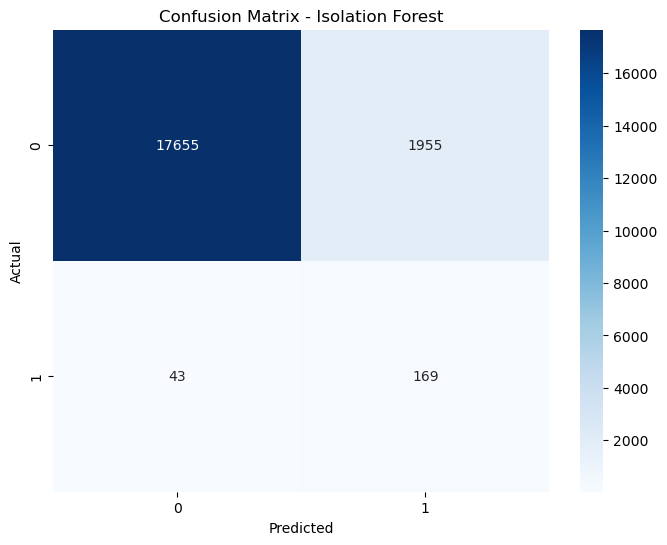

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Isolation Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [9]:
joblib.dump(iso_forest, r'D:\Dataset\Internship Fraud Detection\models\isolation_forest.pkl')

['D:\\Dataset\\Internship Fraud Detection\\models\\isolation_forest.pkl']